In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.impute import SimpleImputer


#from google.colab import drive
#drive.mount('/content/drive')

#os.chdir('/content/drive/MyDrive/SB/SB_Project')

df = pd.read_parquet('classification_ring/data/processed/data_ml.parquet')
print(df.shape)

Mounted at /content/drive
(1452411, 38)


In [2]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Feature groups
atchley_features = [
    's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    't_a1', 't_a2', 't_a3', 't_a4', 't_a5'
]

structural_features = [
    's_rsa', 's_phi', 's_psi',
    't_rsa', 't_phi', 't_psi'
]

dssp_features = ['s_ss8', 't_ss8']  # categorical

di3_features_num = ['s_3di_state', 't_3di_state']  # numerical
di3_features_cat = ['s_3di_letter', 't_3di_letter']  # categorical

# ll features combined
all_num = atchley_features + structural_features + di3_features_num
all_cat = dssp_features + di3_features_cat

print("Feature groups defined:")
print(f"  Atchley: {len(atchley_features)} features")
print(f"  Structural: {len(structural_features)} features")
print(f"  DSSP: {len(dssp_features)} features")
print(f"  3Di: {len(di3_features_num + di3_features_cat)} features")
print(f"  All: {len(all_num + all_cat)} features")

Feature groups defined:
  Atchley: 10 features
  Structural: 6 features
  DSSP: 2 features
  3Di: 4 features
  All: 22 features


In [3]:
from sklearn.model_selection import train_test_split

pdb_ids = df['pdb_id'].unique()

train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")

Train: 999083 rows
Val:   238810 rows


In [4]:
def train_and_evaluate(train_df, val_df, num_cols, cat_cols, label_cols, subset_name):

    feature_cols = num_cols + cat_cols
    X_train = train_df[feature_cols].copy()
    Y_train = train_df[label_cols].copy()
    X_val   = val_df[feature_cols].copy()
    Y_val   = val_df[label_cols].copy()

    #One-hot encoding
    if cat_cols:
        X_train = pd.get_dummies(X_train, columns=cat_cols)
        X_val   = pd.get_dummies(X_val,   columns=cat_cols)
        X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)


    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns)

    rf = MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    )
    rf.fit(X_train, Y_train)

    Y_pred = rf.predict(X_val)
    macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)

    # for every class F1
    per_class_f1 = f1_score(Y_val, Y_pred, average=None, zero_division=0)

    print(f"\n{'='*50}")
    print(f"Subset: {subset_name}")
    print(f"  Features used: {len(X_train.columns)}")
    print(f"  Macro F1: {macro_f1:.4f}")
    print(f"  Micro F1: {micro_f1:.4f}")
    for i, label in enumerate(label_cols):
        print(f"    {label}: {per_class_f1[i]:.4f}")

    return {
        'subset': subset_name,
        'n_features': len(X_train.columns),
        'macro_f1': macro_f1,
        'micro_f1': micro_f1,
        'per_class_f1': dict(zip(label_cols, per_class_f1))
    }

print("Helper function defined.")

Helper function defined.


In [5]:
results = []
r = train_and_evaluate(train_df, val_df,
                        num_cols=atchley_features,
                        cat_cols=[],
                        label_cols=label_cols,
                        subset_name='Atchley only')
results.append(r)
r = train_and_evaluate(train_df, val_df,
                        num_cols=structural_features,
                        cat_cols=[],
                        label_cols=label_cols,
                        subset_name='Structural only')
results.append(r)

r = train_and_evaluate(train_df, val_df,
                        num_cols=[],
                        cat_cols=dssp_features,
                        label_cols=label_cols,
                        subset_name='DSSP only')
results.append(r)

r = train_and_evaluate(train_df, val_df,
                        num_cols=di3_features_num,
                        cat_cols=di3_features_cat,
                        label_cols=label_cols,
                        subset_name='3Di only')
results.append(r)

r = train_and_evaluate(train_df, val_df,
                        num_cols=atchley_features + structural_features,
                        cat_cols=dssp_features,
                        label_cols=label_cols,
                        subset_name='All except 3Di')
results.append(r)
r = train_and_evaluate(train_df, val_df,
                        num_cols=all_num,
                        cat_cols=all_cat,
                        label_cols=label_cols,
                        subset_name='All features')
results.append(r)



Subset: Atchley only
  Features used: 10
  Macro F1: 0.5370
  Micro F1: 0.5964
    HBOND: 0.7201
    VDW: 0.5076
    IONIC: 0.4777
    PIPISTACK: 0.8465
    PICATION: 0.3361
    SSBOND: 0.8580
    PIHBOND: 0.0127

Subset: Structural only
  Features used: 6
  Macro F1: 0.2003
  Micro F1: 0.7163
    HBOND: 0.8352
    VDW: 0.5626
    IONIC: 0.0033
    PIPISTACK: 0.0014
    PICATION: 0.0000
    SSBOND: 0.0000
    PIHBOND: 0.0000

Subset: DSSP only
  Features used: 18
  Macro F1: 0.1924
  Micro F1: 0.3464
    HBOND: 0.6764
    VDW: 0.5217
    IONIC: 0.0605
    PIPISTACK: 0.0630
    PICATION: 0.0172
    SSBOND: 0.0054
    PIHBOND: 0.0023

Subset: 3Di only
  Features used: 42
  Macro F1: 0.2060
  Micro F1: 0.3789
    HBOND: 0.7449
    VDW: 0.5459
    IONIC: 0.0621
    PIPISTACK: 0.0616
    PICATION: 0.0176
    SSBOND: 0.0072
    PIHBOND: 0.0028

Subset: All except 3Di
  Features used: 34
  Macro F1: 0.5334
  Micro F1: 0.7424
    HBOND: 0.8486
    VDW: 0.5866
    IONIC: 0.4288
    PIPISTACK: 

In [6]:
summary = pd.DataFrame([{
    'Subset': r['subset'],
    'N Features': r['n_features'],
    'Macro F1': round(r['macro_f1'], 4),
    'Micro F1': round(r['micro_f1'], 4),
    **{label: round(r['per_class_f1'][label], 4) for label in label_cols}
} for r in results])

summary = summary.sort_values('Macro F1', ascending=False)
print(summary.to_string(index=False))

         Subset  N Features  Macro F1  Micro F1  HBOND    VDW  IONIC  PIPISTACK  PICATION  SSBOND  PIHBOND
   All features          76    0.5398    0.7587 0.8600 0.6149 0.4319     0.8406    0.1156  0.8972   0.0187
   Atchley only          10    0.5370    0.5964 0.7201 0.5076 0.4777     0.8465    0.3361  0.8580   0.0127
 All except 3Di          34    0.5334    0.7424 0.8486 0.5866 0.4288     0.8353    0.1322  0.8836   0.0186
       3Di only          42    0.2060    0.3789 0.7449 0.5459 0.0621     0.0616    0.0176  0.0072   0.0028
Structural only           6    0.2003    0.7163 0.8352 0.5626 0.0033     0.0014    0.0000  0.0000   0.0000
      DSSP only          18    0.1924    0.3464 0.6764 0.5217 0.0605     0.0630    0.0172  0.0054   0.0023


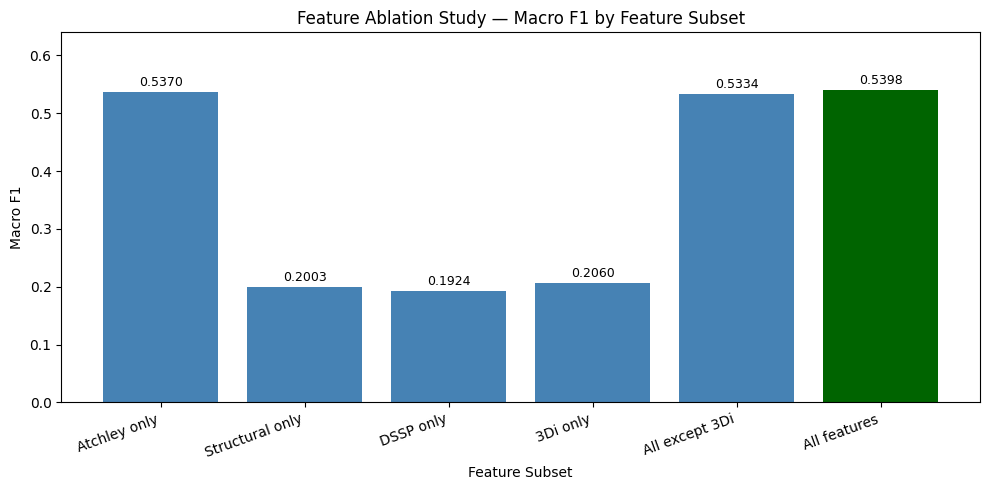

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

subsets = [r['subset'] for r in results]
macro_f1s = [r['macro_f1'] for r in results]

colors = ['steelblue' if s != 'All features' else 'darkgreen' for s in subsets]
bars = ax.bar(subsets, macro_f1s, color=colors)
for bar, val in zip(bars, macro_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Feature Subset')
ax.set_ylabel('Macro F1')
ax.set_title('Feature Ablation Study — Macro F1 by Feature Subset')
ax.set_ylim(0, max(macro_f1s) + 0.1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('ablation_macro_f1.png', dpi=150)
plt.show()

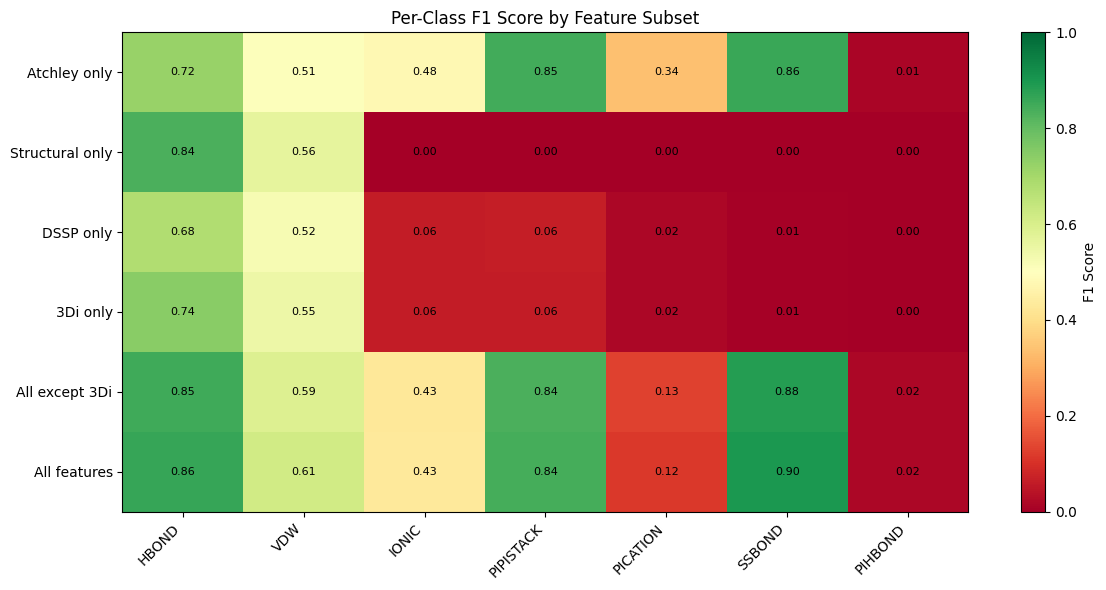

In [8]:

heatmap_data = pd.DataFrame(
    [{**{'Subset': r['subset']}, **r['per_class_f1']} for r in results]
).set_index('Subset')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(label_cols)))
ax.set_xticklabels(label_cols, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data)):
    for j in range(len(label_cols)):
        ax.text(j, i, f'{heatmap_data.values[i,j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Per-Class F1 Score by Feature Subset')
plt.tight_layout()
plt.savefig('ablation_heatmap.png', dpi=150)
plt.show()

In [9]:

best = summary.iloc[0]
worst = summary.iloc[-1]

print(f"\nBest subset: {best['Subset']} (Macro F1 = {best['Macro F1']})")
print(f"Worst subset: {worst['Subset']} (Macro F1 = {worst['Macro F1']})")

all_f1    = summary[summary['Subset'] == 'All features']['Macro F1'].values[0]
no_3di_f1 = summary[summary['Subset'] == 'All except 3Di']['Macro F1'].values[0]
only_3di  = summary[summary['Subset'] == '3Di only']['Macro F1'].values[0]

print(f"\nImpact of 3Di features:")
print(f"  All features:     {all_f1:.4f}")
print(f"  Without 3Di:      {no_3di_f1:.4f}")
print(f"  Drop from 3Di:    {all_f1 - no_3di_f1:.4f}")
print(f"  3Di alone:        {only_3di:.4f}")


Best subset: All features (Macro F1 = 0.5398)
Worst subset: DSSP only (Macro F1 = 0.1924)

Impact of 3Di features:
  All features:     0.5398
  Without 3Di:      0.5334
  Drop from 3Di:    0.0064
  3Di alone:        0.2060
